In [25]:
from nsga2 import Nsga2
from solution import Solution
from datetime import datetime
import time
import pickle
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from sklearn.preprocessing import StandardScaler
from skimage.filters import gaussian
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score, average_precision_score
from imblearn.metrics import geometric_mean_score
from sklearn_extensions.models.elm import ELMClassifier
from pymoo.indicators.hv import HV

In [26]:
load_from_disk = True

if load_from_disk:
    nsga = Nsga2(generator_population_size=1, seed=42)
    nsga.pareto_history = pickle.load(open("data/history/2026-09-10--11:07:01.pkl", 'rb'))
    nsga.generation_count = 1500

    reconstructed_population = []
    for positions, fitness in nsga.pareto_history[-1]:
        gnome = np.zeros(nsga.X_train.shape[1], dtype=int)
        for pos in positions:
            gnome[pos] = 1
        solution = Solution(gnome)
        solution.fitness = fitness
        solution.rank = 0
        reconstructed_population.append(solution)
    nsga.population = reconstructed_population
else:
    nsga = Nsga2(generations=1500, generator_population_size=300, cross_type=2, seed=42)
    t0 = time.time()
    nsga.run()
    print(f'Tiempo total: {time.time()-t0}s')
    filename = "data/history/" + datetime.now().strftime("%Y-%m-%d--%H:%M:%S") + ".pkl"
    pickle.dump(nsga.pareto_history, open(filename, 'wb'))

In [27]:
rank0 = nsga.get_pareto_front()
rank0.sort(key=lambda solution: solution.fitness[2])
print("Numero de soluciones en el frente de pareto:", len(rank0), "\n")
for solution in rank0:
    print(solution.fitness)

Numero de soluciones en el frente de pareto: 72 

(0.2661596958174905, 0.02197802197802198, 1)
(0.5191740412979351, 0.0425531914893617, 2)
(0.47019867549668876, 0.08421052631578947, 2)
(0.5885885885885885, 0.25925925925925924, 3)
(0.5349544072948328, 0.2641509433962264, 3)
(0.5276073619631901, 0.336283185840708, 3)
(0.6366197183098592, 0.2777777777777778, 4)
(0.6361185983827493, 0.29357798165137616, 4)
(0.6208791208791209, 0.3090909090909091, 4)
(0.6050420168067226, 0.3333333333333333, 4)
(0.5333333333333333, 0.336283185840708, 4)
(0.5207100591715976, 0.35398230088495575, 4)
(0.656, 0.358974358974359, 5)
(0.6363636363636364, 0.3684210526315789, 5)
(0.6267806267806267, 0.3793103448275862, 5)
(0.6144927536231884, 0.4132231404958678, 5)
(0.6703296703296703, 0.10416666666666667, 6)
(0.6573816155988857, 0.3508771929824561, 6)
(0.6504065040650406, 0.39669421487603307, 6)
(0.6384180790960452, 0.4098360655737705, 6)
(0.6741573033707865, 0.3333333333333333, 7)
(0.6611570247933884, 0.35398230088

In [28]:
rank0.sort(key=lambda solution: (solution.fitness[0] + solution.fitness[1])/2, reverse=True)
for solution in rank0:
    print(solution.fitness)

(0.6515580736543909, 0.5757575757575758, 33)
(0.6853932584269663, 0.5396825396825397, 27)
(0.6829268292682927, 0.5396825396825397, 18)
(0.6779661016949152, 0.5426356589147286, 32)
(0.6593406593406593, 0.5538461538461539, 22)
(0.6392961876832844, 0.5736434108527132, 30)
(0.6498599439775911, 0.5588235294117647, 27)
(0.6457142857142857, 0.5625, 22)
(0.6345609065155807, 0.5736434108527132, 16)
(0.6477272727272727, 0.5555555555555556, 22)
(0.6104651162790697, 0.5846153846153846, 30)
(0.6121212121212121, 0.578125, 27)
(0.6685236768802229, 0.5196850393700787, 13)
(0.644808743169399, 0.5396825396825397, 15)
(0.6361031518624641, 0.5354330708661418, 14)
(0.7037037037037037, 0.4666666666666667, 12)
(0.6477272727272727, 0.5203252032520326, 16)
(0.6871508379888268, 0.48, 19)
(0.65, 0.512, 12)
(0.6595174262734584, 0.5, 12)
(0.6035502958579881, 0.5538461538461539, 15)
(0.6775956284153005, 0.4793388429752066, 16)
(0.679144385026738, 0.47244094488188976, 15)
(0.6666666666666666, 0.4838709677419355, 12)

Text(0, 0.5, 'F1 Score Olas de calor')

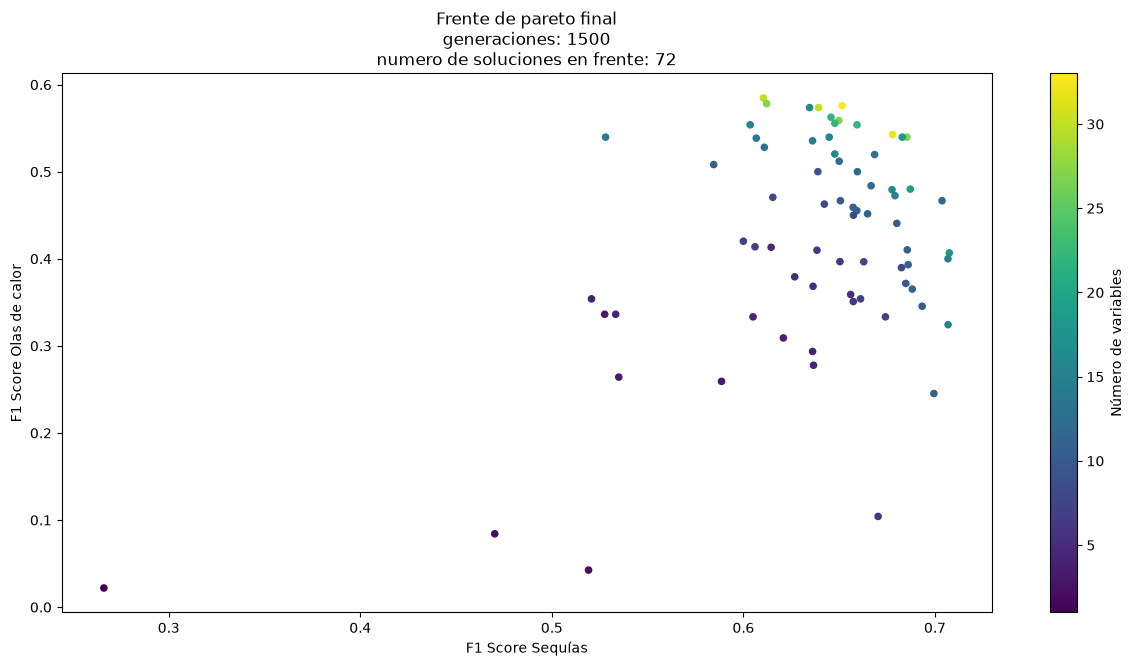

In [29]:
list_dr = []
list_hw = []
list_n_vars = []

for solution in rank0:
    list_dr.append(solution.fitness[0])
    list_hw.append(solution.fitness[1])
    list_n_vars.append(solution.fitness[2])

plt.figure(figsize=(15, 7))
plt.scatter(list_dr, list_hw, c=list_n_vars, cmap='viridis', s=20)
plt.title(f"Frente de pareto final\ngeneraciones: {nsga.generation_count}\nnumero de soluciones en frente: {len(rank0)}")
plt.colorbar(label='Número de variables')
plt.xlabel("F1 Score Sequías")
plt.ylabel("F1 Score Olas de calor")

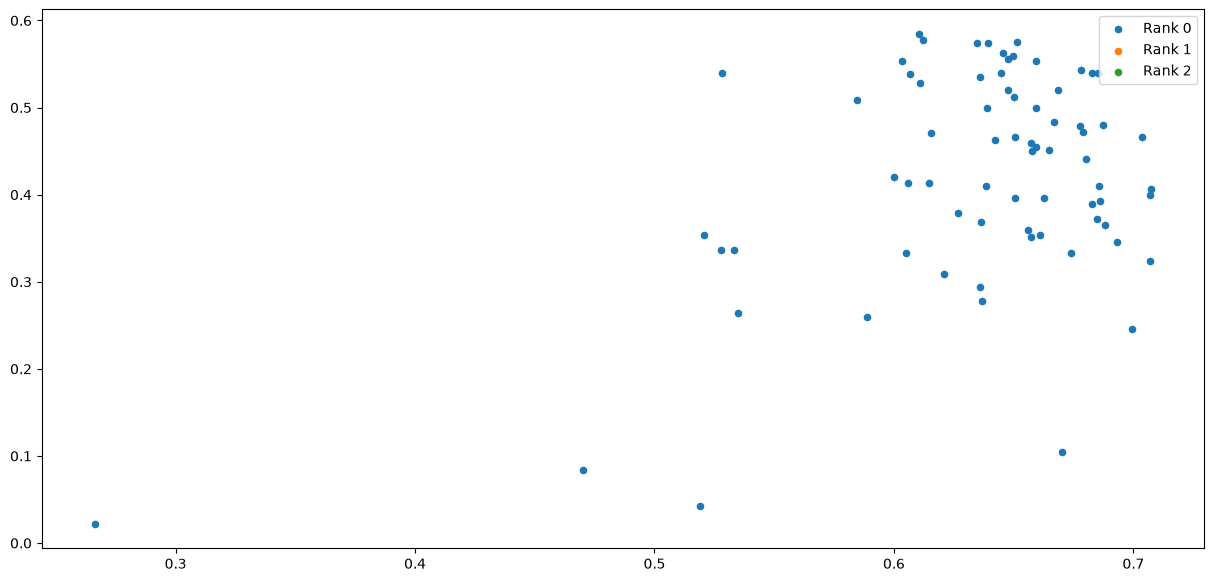

In [30]:
ranks_to_show = [0, 1, 2]
plt.figure(figsize=(15,7))

for rank in ranks_to_show:
    paleto = nsga.get_pareto_front(rank)
    list_dr = []
    list_hw = []
    for solution in paleto:
        list_dr.append(solution.fitness[0])
        list_hw.append(solution.fitness[1])
    plt.scatter(list_dr, list_hw, label=f'Rank {rank}', s=20)

plt.legend()

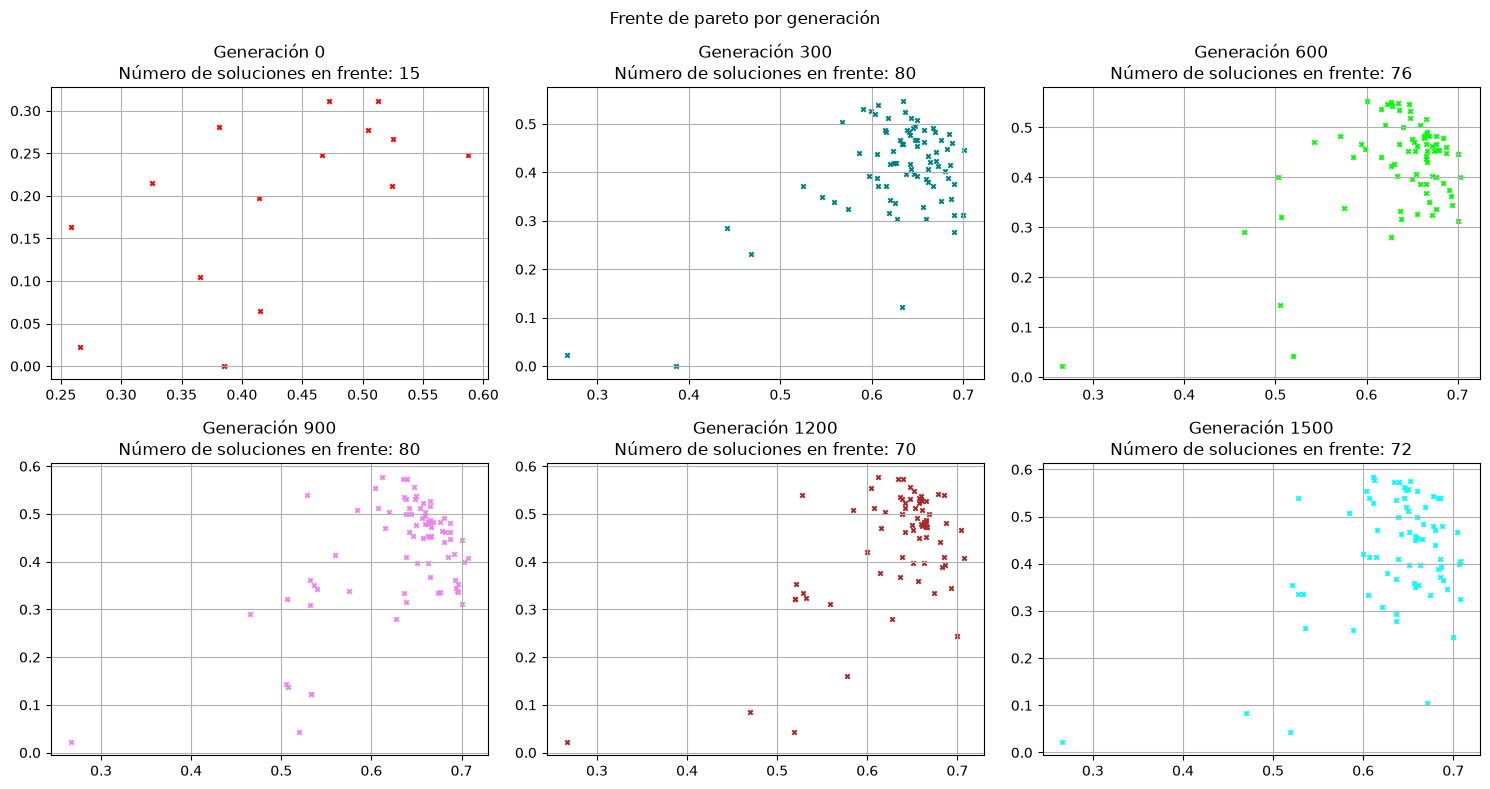

In [31]:
generations = [0, 300, 600, 900, 1200, 1500]
colors = ["red", "teal", "lime", "violet", "brown", "cyan"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
for ax, gen, color in zip(axs, generations, colors):
    history = nsga.pareto_history[gen]
    list_dr = []
    list_hw = []
    
    for posiciones, fitness in history:
        list_dr.append(fitness[0])
        list_hw.append(fitness[1])
        
    ax.scatter(list_dr, list_hw, marker="x", color=color, s=10)
    ax.set_title(f'Generación {gen}\nNúmero de soluciones en frente: {len(nsga.pareto_history[gen])}')
    ax.grid()
plt.suptitle("Frente de pareto por generación")
plt.tight_layout()

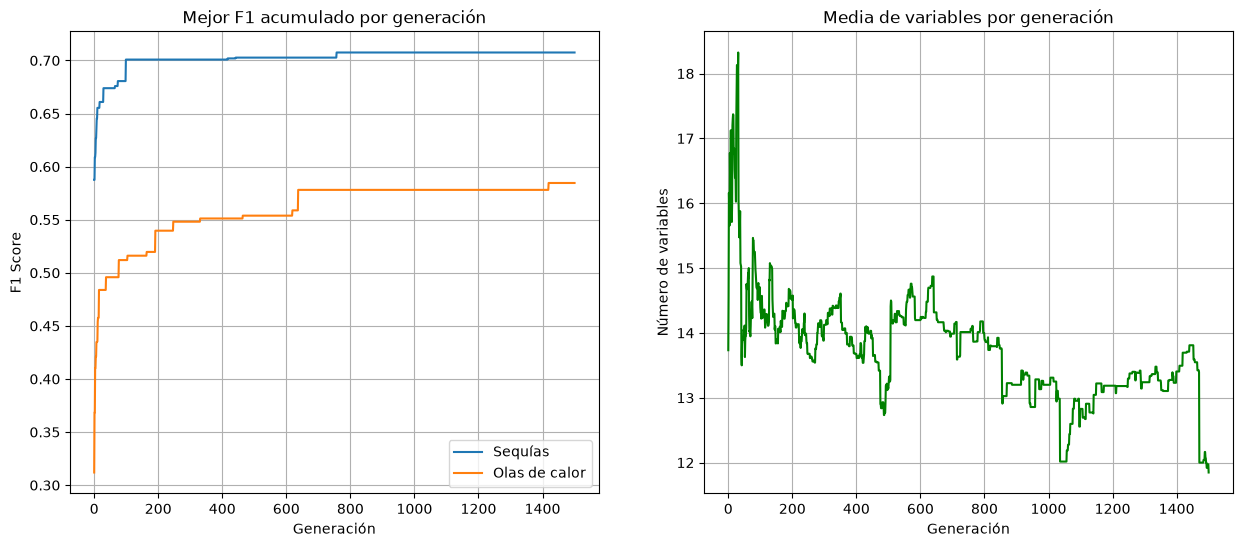

In [32]:
biggest_f1_dr = -1
biggest_f1_hw = -1
biggest_f1_dr_per_gen = []
biggest_f1_hw_per_gen = []
mean_var_per_gen = []

for generation in nsga.pareto_history:
    variables = []
    for positions, fitness in generation:
        if fitness[0] > biggest_f1_dr:
            biggest_f1_dr = fitness[0]
        if fitness[1] > biggest_f1_hw:
            biggest_f1_hw = fitness[1]
        variables.append(fitness[2])
    biggest_f1_dr_per_gen.append(biggest_f1_dr)
    biggest_f1_hw_per_gen.append(biggest_f1_hw)
    mean_var_per_gen.append(sum(variables)/len(variables))

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].plot(biggest_f1_dr_per_gen, label='Sequías')
axs[0].plot(biggest_f1_hw_per_gen, label='Olas de calor')
axs[0].set_xlabel('Generación')
axs[0].set_ylabel('F1 Score')
axs[0].set_title('Mejor F1 acumulado por generación')
axs[0].legend()
axs[0].grid()

axs[1].plot(mean_var_per_gen, color='green')
axs[1].set_xlabel('Generación')
axs[1].set_ylabel('Número de variables')
axs[1].set_title('Media de variables por generación')
axs[1].grid()

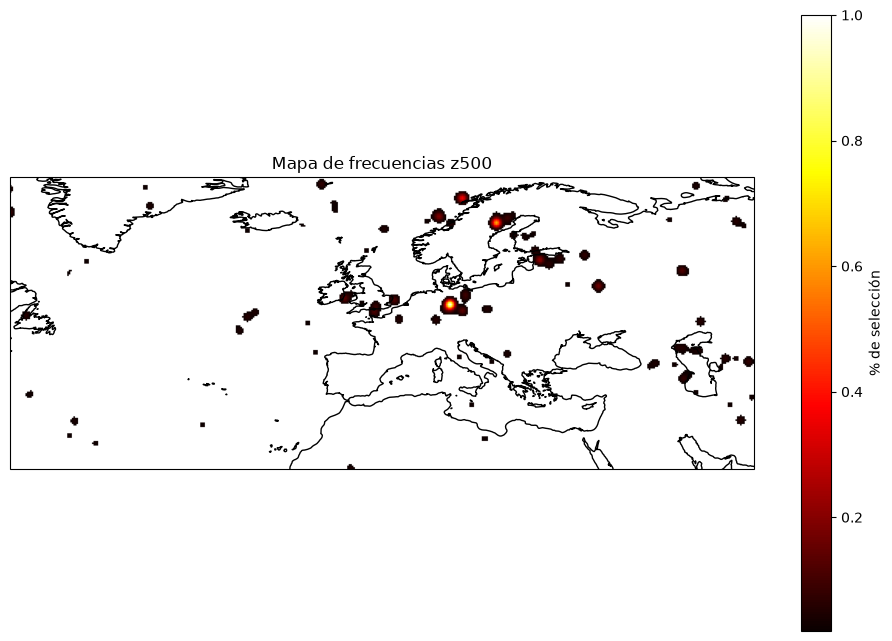

In [33]:
map_z500 = np.zeros((189, 481))
map_rh = np.zeros((189, 481))
for positions, fitness in nsga.pareto_history[-1]:
    for pos in positions:
        lat_idx, lon_idx, var_idx = np.unravel_index(pos, (189, 481, 2))
        if var_idx == 0:
            map_z500[lat_idx, lon_idx] += 1
        else:
            map_rh[lat_idx, lon_idx] += 1

map_z500 = gaussian(map_z500, sigma=2)
map_z500_masked = np.ma.masked_less(map_z500, 0.05)
map_z500_normalized = map_z500_masked / map_z500_masked.max()

ds = xr.open_dataset('data/preprocessed/predictoras.nc')
extent = [ds.lon.values.min(), ds.lon.values.max(), ds.lat.values.min(), ds.lat.values.max()]

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_extent(extent, crs=ccrs.PlateCarree())
im = ax.imshow(map_z500_normalized, extent=extent, origin='upper', cmap='hot', transform=ccrs.PlateCarree())
plt.colorbar(im, label='% de selección')
plt.title("Mapa de frecuencias z500")
plt.show()

Solución con mejor F1_Drought
Métrica - Entrenamiento - Validación
------------------------------------

OLAS DE CALOR
           F1 - 0.2778675282714055 - 0.4067796610169492
    Precision - 0.6099290780141844 - 0.8571428571428571
       Recall - 0.1799163179916318 - 0.26666666666666666
Bal. Accuracy - 0.5851563430363258 - 0.6302083333333334
      G. Mean - 0.4221237589823889 - 0.51478150704935
       PR-AUC - 0.43474692471631315 - 0.6635431253722324

SEQUIAS
           F1 - 0.6000696136442742 - 0.7075208913649025
    Precision - 0.6884984025559105 - 0.7839506172839507
       Recall - 0.5317705120296113 - 0.6446700507614214
Bal. Accuracy - 0.7233459889990989 - 0.7895020047428121
      G. Mean - 0.6975157750366637 - 0.7761038078755003
       PR-AUC - 0.6686367120649412 - 0.752916937961659


Solución con mejor F1_Heatwave
Métrica - Entrenamiento - Validación
------------------------------------

OLAS DE CALOR
           F1 - 0.34597875569044007 - 0.5846153846153846
    Precision - 0.6298

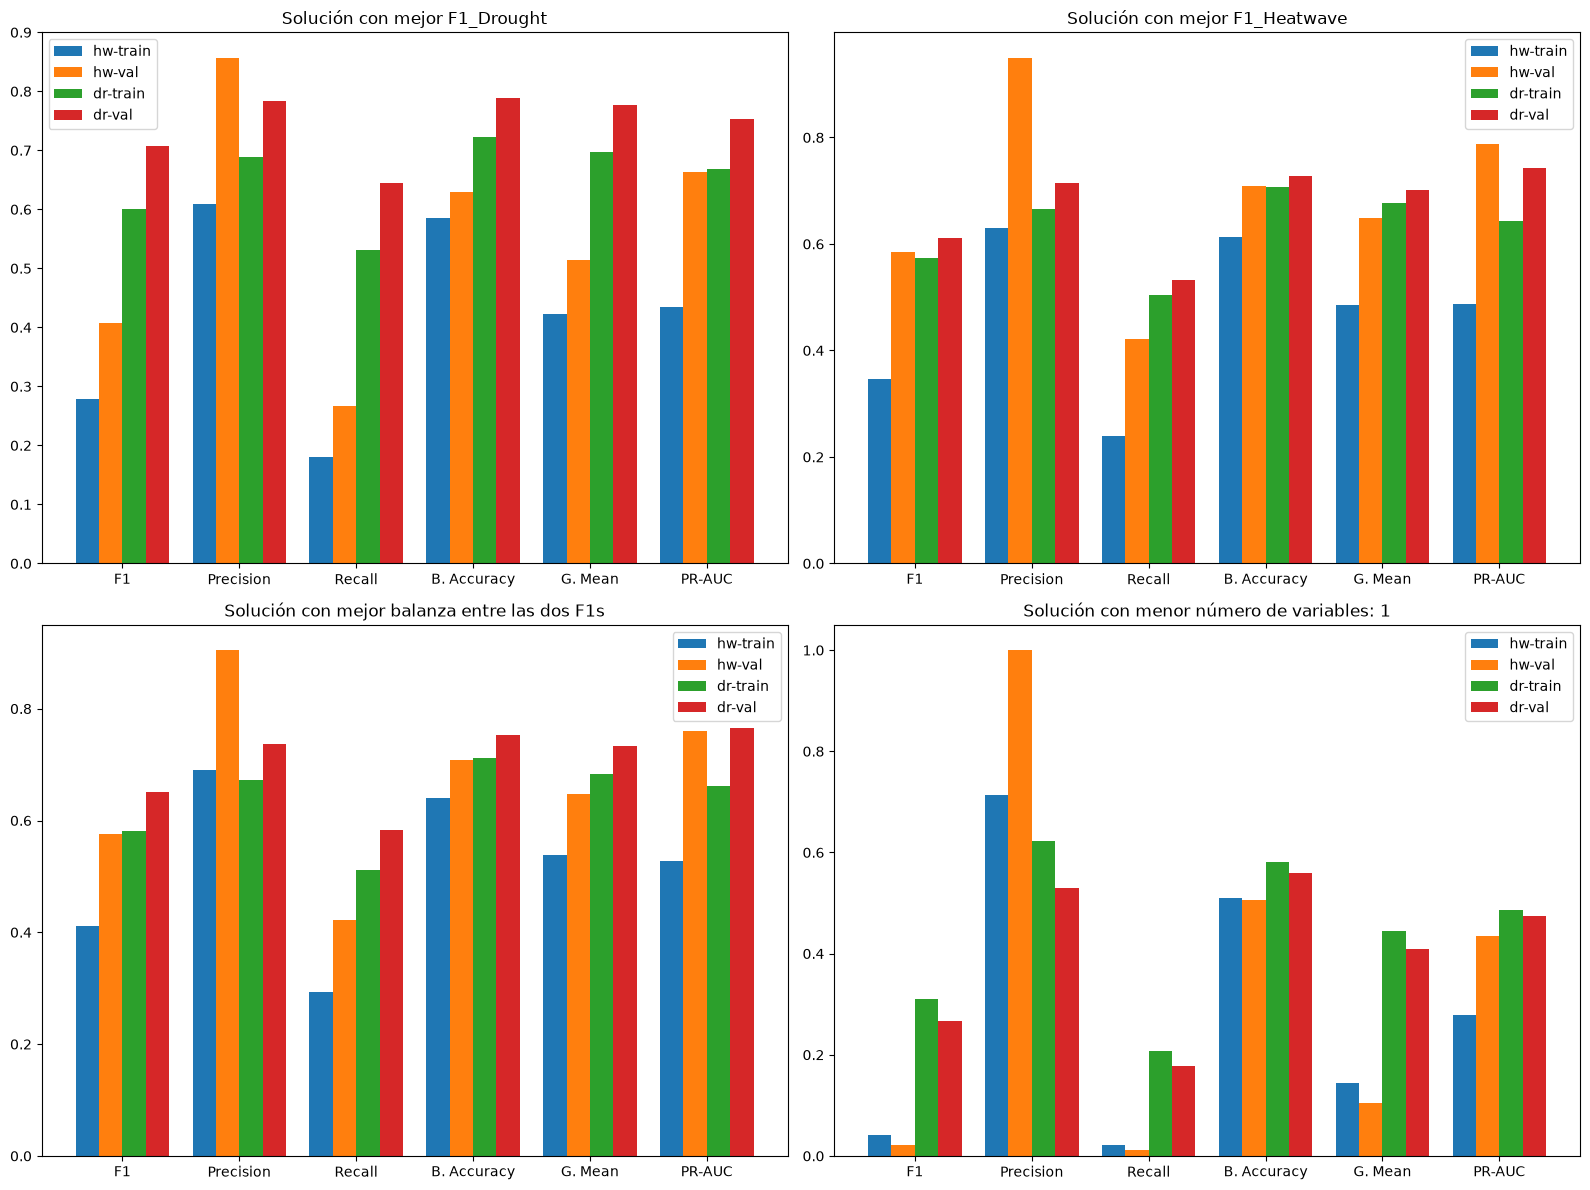

In [34]:
sorted_list = nsga.get_pareto_front()
solutions = []

# Solución con mejor F1_Drought
sorted_list.sort(key=lambda solution: (solution.fitness[0]), reverse=True)
solutions.append(sorted_list[0])

# Solución con mejor F1_Heatwave
sorted_list.sort(key=lambda solution: (solution.fitness[1]), reverse=True)
solutions.append(sorted_list[0])

# Solución con mejor balanza entre las dos F1s
sorted_list.sort(key=lambda solution: (solution.fitness[0] + solution.fitness[1])/2, reverse=True)
solutions.append(sorted_list[0])

# Solución con menor número de variables
sorted_list.sort(key=lambda solution: (solution.fitness[2]))
fourth_title = f'Solución con menor número de variables: {sorted_list[0].fitness[2]}'
solutions.append(sorted_list[0])

titles = ['Solución con mejor F1_Drought', 
          'Solución con mejor F1_Heatwave', 
          'Solución con mejor balanza entre las dos F1s',
          fourth_title]

random_state=96

scaler = StandardScaler()

y_hw_train = nsga.y_train['hw'] # Heatwave train y set
y_dr_train = nsga.y_train['dr'] # Drought train y set

y_hw_val = nsga.y_val['hw'] # Heatwave validation y set
y_dr_val = nsga.y_val['dr'] # Drought validation y set

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for ax, solution, title in zip(axs, solutions, titles):
    X_train = nsga.X_train[:, solution.gnome == 1]
    X_val = nsga.X_val[:, solution.gnome == 1]

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)    

    # - Declaration and training -

    # Model declaration
    modelo_hw = ELMClassifier(hidden_layer_size=60, random_state=random_state) # Heatwaves
    modelo_dr = ELMClassifier(hidden_layer_size=60, random_state=random_state) # Droughts

    # Model training
    modelo_hw.fit(X_train, y_hw_train) # Heatwaves
    modelo_dr.fit(X_train, y_dr_train) # Droughts

    # - Predictions -

    # Predictions with training set
    y_hw_pred_train = modelo_hw.predict(X_train) # Heatwaves
    y_dr_pred_train = modelo_dr.predict(X_train) # Droughts

    # Predictions with validation set
    y_hw_pred = modelo_hw.predict(X_val) # Heatwaves
    y_dr_pred = modelo_dr.predict(X_val) # Droughts

    # - Probabilites -
    
    # Prediction probabilities with training set
    y_hw_proba_train = modelo_hw.predict_proba(X_train)[:, 1]
    y_dr_proba_train = modelo_dr.predict_proba(X_train)[:, 1]
    
    # Prediction probabilities validation set
    y_hw_proba = modelo_hw.predict_proba(X_val)[:, 1]
    y_dr_proba = modelo_dr.predict_proba(X_val)[:, 1]

    # - Scores -

    # Heatwave training set scores
    f1_hw_train = f1_score(y_hw_train, y_hw_pred_train)
    rec_hw_train = recall_score(y_hw_train, y_hw_pred_train, zero_division=0)
    pre_hw_train = precision_score(y_hw_train, y_hw_pred_train, zero_division=0)
    bal_hw_train = balanced_accuracy_score(y_hw_train, y_hw_pred_train)
    gmean_hw_train = geometric_mean_score(y_hw_train, y_hw_pred_train)
    prauc_hw_train = average_precision_score(y_hw_train, y_hw_proba_train)

    # Heatwave validation set scores
    f1_hw = f1_score(y_hw_val, y_hw_pred)
    rec_hw = recall_score(y_hw_val, y_hw_pred, zero_division=0)
    pre_hw = precision_score(y_hw_val, y_hw_pred, zero_division=0)
    bal_hw = balanced_accuracy_score(y_hw_val, y_hw_pred)
    gmean_hw = geometric_mean_score(y_hw_val, y_hw_pred)
    prauc_hw = average_precision_score(y_hw_val, y_hw_proba)
    
    # Drought training set scores
    f1_dr_train = f1_score(y_dr_train, y_dr_pred_train)
    rec_dr_train = recall_score(y_dr_train, y_dr_pred_train, zero_division=0)
    pre_dr_train = precision_score(y_dr_train, y_dr_pred_train, zero_division=0)
    bal_dr_train = balanced_accuracy_score(y_dr_train, y_dr_pred_train)
    gmean_dr_train = geometric_mean_score(y_dr_train, y_dr_pred_train)
    prauc_dr_train = average_precision_score(y_dr_train, y_dr_proba_train)

    # Drought validation set scores
    f1_dr = f1_score(y_dr_val, y_dr_pred)
    rec_dr = recall_score(y_dr_val, y_dr_pred, zero_division=0)
    pre_dr = precision_score(y_dr_val, y_dr_pred, zero_division=0)
    bal_dr = balanced_accuracy_score(y_dr_val, y_dr_pred)
    gmean_dr = geometric_mean_score(y_dr_val, y_dr_pred)
    prauc_dr = average_precision_score(y_dr_val, y_dr_proba)

    # - Prints -

    # General
    print(title)
    print('Métrica - Entrenamiento - Validación')
    print('------------------------------------')

    # Heatwave prints
    print('\nOLAS DE CALOR')
    print('           F1 -', f1_hw_train, '-', f1_hw)
    print('    Precision -', pre_hw_train, '-', pre_hw)
    print('       Recall -', rec_hw_train, '-', rec_hw)
    print('Bal. Accuracy -', bal_hw_train, '-', bal_hw)
    print('      G. Mean -', gmean_hw_train, '-', gmean_hw)
    print('       PR-AUC -', prauc_hw_train, '-', prauc_hw)

    # Droughts prints
    print('\nSEQUIAS')
    print('           F1 -', f1_dr_train, '-', f1_dr)
    print('    Precision -', pre_dr_train, '-', pre_dr)
    print('       Recall -', rec_dr_train, '-', rec_dr)
    print('Bal. Accuracy -', bal_dr_train, '-', bal_dr)
    print('      G. Mean -', gmean_dr_train, '-', gmean_dr)
    print('       PR-AUC -', prauc_dr_train, '-', prauc_dr)

    # - Line break between iterations -
    print('\n')

    metrics = ['F1', 'Precision', 'Recall', 'B. Accuracy', 'G. Mean', 'PR-AUC']
    x_references = np.array([0, 2, 4, 6, 8, 10])
    width = 0.4

    # Heatwave train scores
    hw_train_values = [f1_hw_train, pre_hw_train, rec_hw_train, bal_hw_train, gmean_hw_train, prauc_hw_train]
    
    # Heatwave validation scores
    hw_val_values   = [f1_hw, pre_hw, rec_hw, bal_hw, gmean_hw, prauc_hw]
    
    # Drought train scores
    dr_train_values = [f1_dr_train, pre_dr_train, rec_dr_train, bal_dr_train, gmean_dr_train, prauc_dr_train]
    
    # Drought validation scores
    dr_val_values   = [f1_dr, pre_dr, rec_dr, bal_dr, gmean_dr, prauc_dr]

    ax.bar(x_references - 1.5*width, hw_train_values, width, label='hw-train')
    ax.bar(x_references - 0.5*width, hw_val_values,   width, label='hw-val')
    ax.bar(x_references + 0.5*width, dr_train_values, width, label='dr-train')
    ax.bar(x_references + 1.5*width, dr_val_values,   width, label='dr-val')

    ax.set_xticks(x_references)
    ax.set_xticklabels(metrics)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()

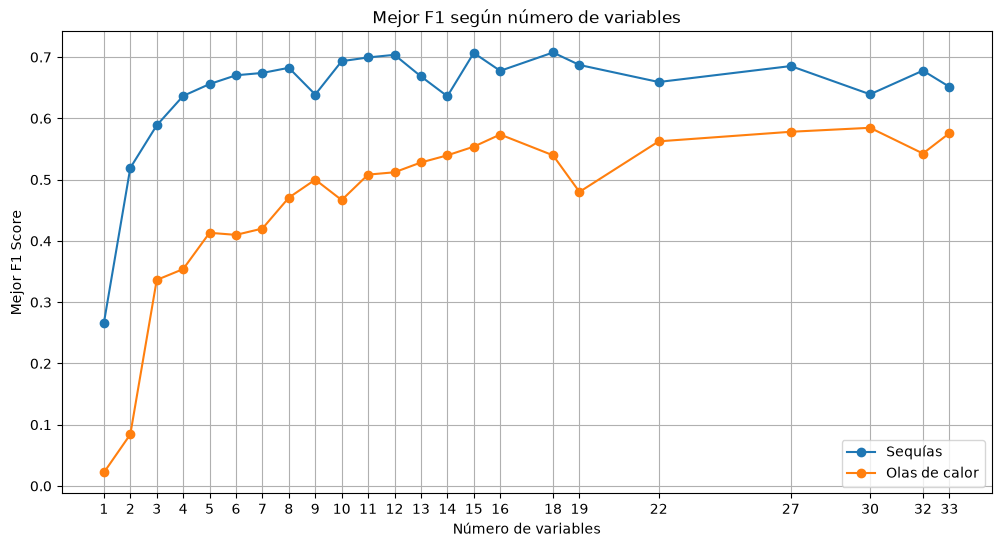

In [40]:
rank0 = nsga.get_pareto_front()

best_dr_dict = {}
best_hw_dict = {}

for solution in rank0:
    f1_dr, f1_hw, n_vars = solution.fitness

    if n_vars not in best_dr_dict or f1_dr > best_dr_dict[n_vars]:
        best_dr_dict[n_vars] = f1_dr

    if n_vars not in best_hw_dict or f1_hw > best_hw_dict[n_vars]:
        best_hw_dict[n_vars] = f1_hw

best_dr_dict_sorted = sorted(best_dr_dict.keys())
f1_best_dr = []
for n_vars in best_dr_dict_sorted:
    val = best_dr_dict[n_vars]
    f1_best_dr.append(val)

best_hw_dict_sorted = sorted(best_hw_dict.keys())
f1_best_hw = []
for n_vars in best_hw_dict_sorted:
    val = best_hw_dict[n_vars]
    f1_best_hw.append(val)

plt.figure(figsize=(12, 6))
plt.plot(best_dr_dict_sorted, f1_best_dr, marker='o', label='Sequías')
plt.plot(best_hw_dict_sorted, f1_best_hw, marker='o', label='Olas de calor')
plt.xlabel('Número de variables')
plt.ylabel('Mejor F1 Score')
plt.xticks(best_dr_dict_sorted)
plt.title('Mejor F1 según número de variables')
plt.legend()
plt.grid()

Hipervolumen del frente: 18.34252176585968


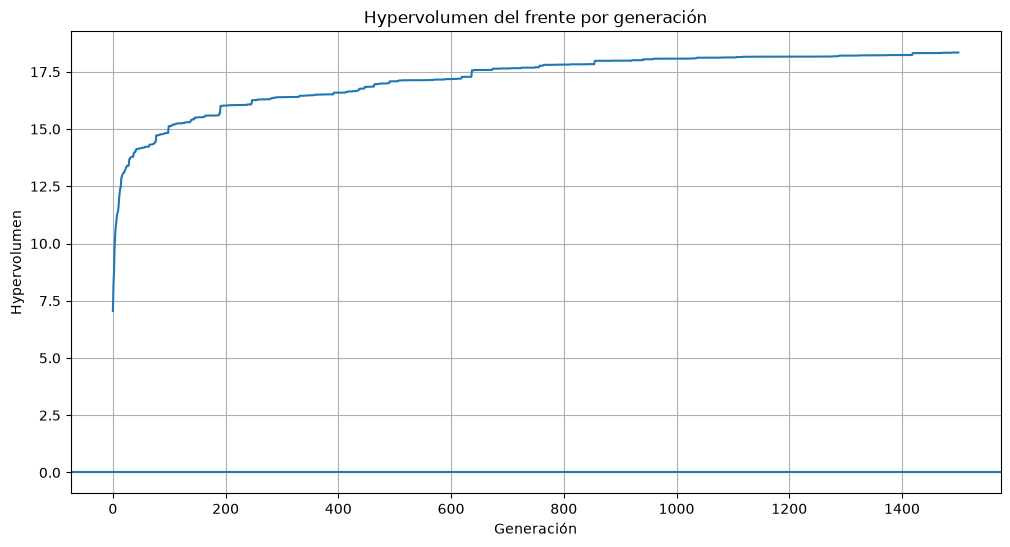

In [ ]:
rank0 = nsga.get_pareto_front()

points = []
for solution in rank0:
    row = [-solution.fitness[0], -solution.fitness[1], solution.fitness[2]]
    points.append(row)
points = np.array(points)

reference = np.array([0, 0, nsga.max_active_vars + 1])

hv = HV(ref_point=reference)
hypervolume = hv(points)

print("Hipervolumen del frente:", hypervolume)

hypervolume_per_gen = []

for generation in nsga.pareto_history:
    points = []
    for positions, fitness in generation:
        row_gen = [-fitness[0], -fitness[1], fitness[2]]
        points.append(row_gen)
    points = np.array(points)
    hv_value = hv(points)
    hypervolume_per_gen.append(hv_value)

plt.figure(figsize=(12, 6))
plt.plot(hypervolume_per_gen)
plt.axhline(0)
plt.xlabel('Generación')
plt.ylabel('Hypervolumen')
plt.title('Hypervolumen del frente por generación')
plt.grid()